# DNA Sequence Analysis & Visualization

A pipeline that loads DNA sequences, computes nucleotide composition,
GC content, and melting temperature using **Biopython**, stores the
results in **SQLite**, queries them with **SQL**, and visualizes
patterns across organisms with **Matplotlib**.

**Pipeline:** CSV → Biopython analysis → SQLite → SQL queries → charts


## 1. Load the raw sequences

In [1]:
import csv
import sqlite3
from Bio.Seq import Seq
from Bio.SeqUtils import gc_fraction
from Bio.SeqUtils import MeltingTemp as mt
import matplotlib.pyplot as plt

with open("data/sequences.csv", newline="") as f:
    raw_sequences = list(csv.DictReader(f))

print(f"Loaded {len(raw_sequences)} raw sequences")
raw_sequences[:3]


Loaded 30 raw sequences


[{'sequence_id': 'DNA001',
  'organism': 'Human',
  'sequence': 'CCAACTATGCGCTACAAACAGATGGTAAAGCGGGTATTGTGTAGTTCCCAGATCGATTCTCATTGATGAAACGACCTCTTTGACCTCAAATTTATAGCATAATGGTTCGCACAGGATCGTG'},
 {'sequence_id': 'DNA002',
  'organism': 'Human',
  'sequence': 'CCGATGAACTCGCAGGATAAGCGATCAAGATTATCTGCGGTTTGGATACTTTTCATTCGAAGAATAGGGCCACATAGACCATTTATCCATTCGTTA'},
 {'sequence_id': 'DNA003',
  'organism': 'Human',
  'sequence': 'CTAATATAACGGGTTGGTCGGCTAGTCGTCTGTGCGTTAAGTAATTAGCGAAAACCGGATATCACGCACGTACCTTTGTTGCTATCAGGTCGTAACACACTCTACCAACAGAGTTATATTAATTAGATGTACAGCATGCAC'}]

## 2. Analyze each sequence with Biopython

For every sequence we compute:
- **GC content** — proportion of G/C bases (`Bio.SeqUtils.gc_fraction`)
- **Melting temperature (Tm)** — estimated using the GC-based empirical
  formula (`Tm_GC`), which is appropriate for sequences longer than a
  short primer (unlike the simpler Wallace rule, which only works for
  sequences under ~14bp)
- **Nucleotide counts** — raw A/T/G/C counts


In [2]:
def analyze_sequence(sequence: str) -> dict:
    seq_obj = Seq(sequence.upper())
    gc_pct = round(gc_fraction(seq_obj) * 100, 2)
    tm = round(mt.Tm_GC(seq_obj), 2)
    counts = {base: sequence.upper().count(base) for base in "ATGC"}
    return {
        "length": len(sequence),
        "gc_content": gc_pct,
        "at_content": round(100 - gc_pct, 2),
        "melting_temp": tm,
        "a_count": counts["A"], "t_count": counts["T"],
        "g_count": counts["G"], "c_count": counts["C"],
    }

results = []
for row in raw_sequences:
    metrics = analyze_sequence(row["sequence"])
    results.append({**row, **metrics})

results[0]


{'sequence_id': 'DNA001',
 'organism': 'Human',
 'sequence': 'CCAACTATGCGCTACAAACAGATGGTAAAGCGGGTATTGTGTAGTTCCCAGATCGATTCTCATTGATGAAACGACCTCTTTGACCTCAAATTTATAGCATAATGGTTCGCACAGGATCGTG',
 'length': 121,
 'gc_content': 42.98,
 'at_content': 57.02,
 'melting_temp': 72.56,
 'a_count': 35,
 't_count': 34,
 'g_count': 26,
 'c_count': 26}

## 3. Load results into SQLite

In [3]:
conn = sqlite3.connect("dna_analysis.db")
cur = conn.cursor()

cur.executescript('''
DROP TABLE IF EXISTS sequences;
CREATE TABLE sequences (
    sequence_id   TEXT PRIMARY KEY,
    organism      TEXT NOT NULL,
    sequence      TEXT NOT NULL,
    length        INTEGER NOT NULL,
    gc_content    REAL NOT NULL,
    at_content    REAL NOT NULL,
    melting_temp  REAL NOT NULL,
    a_count       INTEGER NOT NULL,
    t_count       INTEGER NOT NULL,
    g_count       INTEGER NOT NULL,
    c_count       INTEGER NOT NULL
);
''')

cur.executemany('''
    INSERT INTO sequences
    (sequence_id, organism, sequence, length, gc_content, at_content,
     melting_temp, a_count, t_count, g_count, c_count)
    VALUES (:sequence_id, :organism, :sequence, :length, :gc_content,
            :at_content, :melting_temp, :a_count, :t_count, :g_count, :c_count)
''', results)

conn.commit()
print(f"Loaded {len(results)} rows into dna_analysis.db")


Loaded 30 rows into dna_analysis.db


## 4. Query with SQL

A few questions answered directly in SQL rather than in Python —
this is the kind of thing a database is for.

In [4]:
# Average GC content per organism
cur.execute('''
    SELECT organism, ROUND(AVG(gc_content), 2) AS avg_gc
    FROM sequences
    GROUP BY organism
    ORDER BY avg_gc DESC
''')
for row in cur.fetchall():
    print(row)


('E. coli', 52.16)
('Drosophila', 41.47)
('Human', 41.16)
('Yeast', 38.37)
('Arabidopsis', 36.11)


In [5]:
# Organisms whose average melting temperature exceeds 72°C
cur.execute('''
    SELECT organism, ROUND(AVG(melting_temp), 2) AS avg_tm
    FROM sequences
    GROUP BY organism
    HAVING AVG(melting_temp) > 72
''')
for row in cur.fetchall():
    print(row)


('E. coli', 75.83)


## 5. Visualize

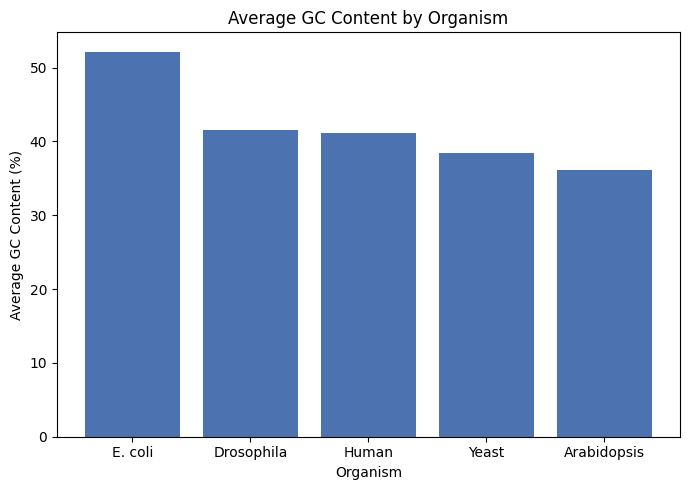

In [6]:
cur.execute('''
    SELECT organism, AVG(gc_content) AS avg_gc
    FROM sequences GROUP BY organism ORDER BY avg_gc DESC
''')
rows = cur.fetchall()
organisms = [r[0] for r in rows]
avg_gc = [r[1] for r in rows]

plt.figure(figsize=(7, 5))
plt.bar(organisms, avg_gc, color="#4C72B0")
plt.xlabel("Organism"); plt.ylabel("Average GC Content (%)")
plt.title("Average GC Content by Organism")
plt.tight_layout()
plt.show()


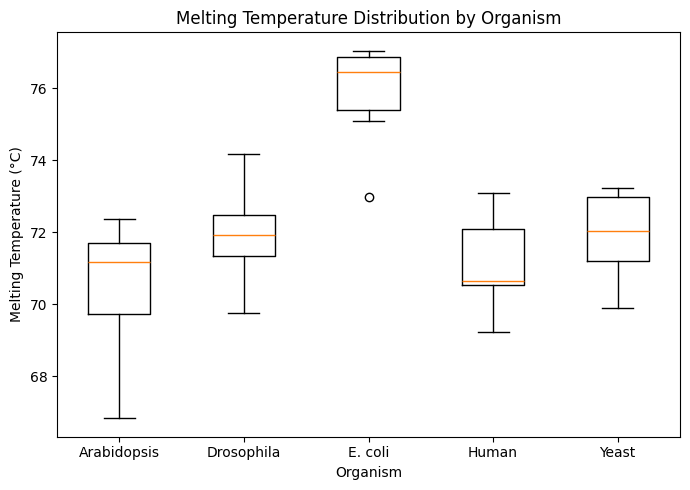

In [7]:
cur.execute("SELECT organism, melting_temp FROM sequences ORDER BY organism")
rows = cur.fetchall()
organisms_sorted = sorted(set(r[0] for r in rows))
data_by_org = [[r[1] for r in rows if r[0] == org] for org in organisms_sorted]

plt.figure(figsize=(7, 5))
plt.boxplot(data_by_org, tick_labels=organisms_sorted)
plt.xlabel("Organism"); plt.ylabel("Melting Temperature (°C)")
plt.title("Melting Temperature Distribution by Organism")
plt.tight_layout()
plt.show()


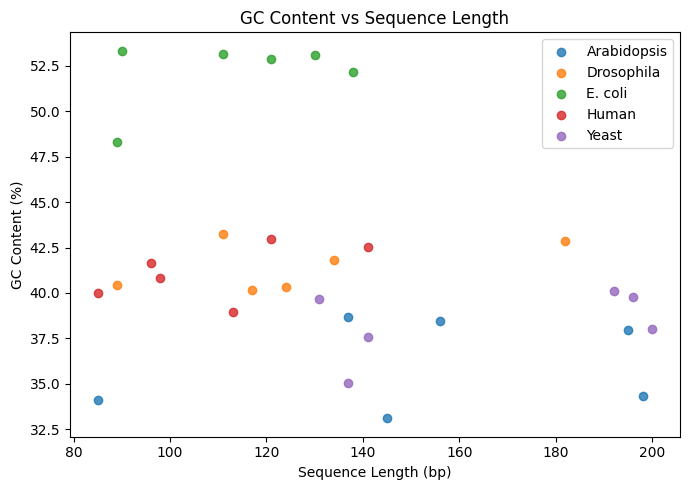

In [8]:
cur.execute("SELECT organism, length, gc_content FROM sequences")
rows = cur.fetchall()
organisms_u = sorted(set(r[0] for r in rows))
colors = plt.cm.tab10.colors

plt.figure(figsize=(7, 5))
for i, org in enumerate(organisms_u):
    xs = [r[1] for r in rows if r[0] == org]
    ys = [r[2] for r in rows if r[0] == org]
    plt.scatter(xs, ys, label=org, color=colors[i % len(colors)], alpha=0.8)
plt.xlabel("Sequence Length (bp)"); plt.ylabel("GC Content (%)")
plt.title("GC Content vs Sequence Length")
plt.legend()
plt.tight_layout()
plt.show()

conn.close()


## Notes

- This notebook currently runs on **synthetic sequences** (`data/sequences.csv`),
  generated within known real-world GC-content ranges per organism.
- `fetch_real_sequences.py` uses Biopython's `Entrez` module to pull **real**
  gene sequences live from NCBI. Swap `data/sequences.csv` for
  `data/real_sequences.csv` after running it to analyze live data instead.
- Melting temperature uses Biopython's `Tm_GC` formula, appropriate for
  sequences longer than a short primer (the simpler Wallace rule only
  holds for sequences under ~14bp).
